## **PADEL SHOT CLASSIFICATION**


Pandas => Dataset retrieval, exploration and preprocessing


Numpy => Utility functions


Scikit-learn => Machine Learning stuff

In [1]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# Installing necessary packages, avoiding lots of rows and show progresses in an elegant way
from tqdm.auto import tqdm
import subprocess
import sys

def packages_installation(packages):
    format = '{desc} {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}'
    description = "Installation (" + ", ".join(packages) + ")"

    pbar = tqdm(packages, total=len(packages), desc = description, bar_format = format)
    for package in pbar:
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", package],
                stdout = subprocess.DEVNULL, stderr = subprocess.PIPE
            )
        except subprocess.CalledProcessError as e:
            pbar.close()
            raise Exception(f"Error during the installation of package {package}")
    pbar.close()
    print("[DONE] Packages have been successfully installed", end="\n\n")

packages_installation(["scikeras", "tensorflow", "m2cgen"])

Installation (scikeras, tensorflow, m2cgen)   0%|          | 0/3

[DONE] Packages have been successfully installed



In [3]:
import m2cgen as m2c
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, LeaveOneGroupOut
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
def plot_confusion_matrix(y_true, y_pred, labels):
    classi_uniche = sorted(y_true.unique())

    cm = confusion_matrix(y_true, y_pred, labels=classi_uniche)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi_uniche)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45) # Ruotato di 45 gradi se i nomi sono lunghi

    plt.title("Confusion Matrix (Cross-Validation)", fontsize=14)
    plt.tight_layout()
    plt.show()

# 1 Data Exploration

In [5]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/MobileProject'

if os.path.exists(path):
    os.chdir(path)
    print(f"Directory impostata su: {os.getcwd()}")
else:
    print("Percorso non trovato. Controlla il nome della cartella su Drive!")

Mounted at /content/drive
Directory impostata su: /content/drive/MyDrive/MobileProject


In [6]:
import os

file_path = 'padel_shots_dataset_score_marker.csv'
full_path = os.path.join(os.getcwd(), file_path)

if os.path.exists(full_path):
    print(f"File '{file_path}' found at '{full_path}'. Attempting to read...")
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully.")
else:
    print(f"Error: File '{file_path}' not found at '{full_path}'.")
    print("Please ensure the file is in your Google Drive folder 'MobileProject' or correct the 'file_path'.")
    print("Current working directory is:", os.getcwd())

File 'padel_shots_dataset_score_marker.csv' found at '/content/drive/MyDrive/MobileProject/padel_shots_dataset_score_marker.csv'. Attempting to read...
DataFrame loaded successfully.


In [7]:
print("--- ANALISI STRUTTURALE ---")
print("rows x columns")
print(df.shape)

# 2. Visualizzazione delle prime righe
print("\nPrime 20 righe:")
display(df.head(40))

# 3. Informazioni generali (Lunghezza, colonne, tipi di dati, valori nulli)
print("\nInformazioni sul DataFrame:")
df.info()

# 4. Statistiche descrittive (Media, deviazione standard, min, max)
print("\nStatistiche descrittive:")
display(df.describe())

# 5. Verifica valori mancanti e duplicati
print(f"\nValori nulli per colonna:\n{df.isnull().sum()}")
print(f"\nRighe duplicate: {df.duplicated().sum()}")

--- ANALISI STRUTTURALE ---
rows x columns
(21828, 10)

Prime 20 righe:


,shot_id,timestamp,score_marker,sample_index,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,0,5.746753,-10.064603,1.145039,0.404147,1.789033,0.026632
1,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,1,5.492832,-10.341281,-0.371299,0.326647,1.848024,-0.427983
2,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,2,4.917917,-10.390389,-0.871954,-0.207999,1.798754,-0.533581
3,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,3,4.897556,-9.591496,-0.731819,-0.700033,1.975460,-0.508546
4,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,4,3.839952,-8.044017,-1.298349,-0.753964,1.881314,-0.510810
5,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,5,4.581353,-7.812853,-1.701987,-0.708556,2.125933,-0.593504
6,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,6,4.272336,-7.648763,-1.349852,-0.573929,2.162553,-0.587644
7,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,7,5.071228,-7.706255,-0.845604,-0.763951,2.370153,-0.628925
8,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,8,5.551521,-8.123068,-1.069581,-0.897513,2.555248,-0.619737
9,1779007883314,2026-05-17 10:51:23.314,S0-0_G0-0,9,5.135906,-8.398548,-1.377400,-1.167033,2.588272,-0.644238



Informazioni sul DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21828 entries, 0 to 21827
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   shot_id       21828 non-null  int64  
 1   timestamp     21828 non-null  object 
 2   score_marker  21828 non-null  object 
 3   sample_index  21828 non-null  int64  
 4   acc_x         21828 non-null  float64
 5   acc_y         21828 non-null  float64
 6   acc_z         21828 non-null  float64
 7   gyro_x        21828 non-null  float64
 8   gyro_y        21828 non-null  float64
 9   gyro_z        21828 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 1.7+ MB

Statistiche descrittive:


,shot_id,sample_index,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
count,2.182800e+04,21828.000000,21828.000000,21828.000000,21828.000000,21828.000000,21828.000000,21828.000000
mean,1.779011e+12,25.000000,9.228170,-5.247256,-0.296290,-0.080921,-0.238871,-0.298559
std,1.570703e+06,14.719939,13.331137,6.852385,9.074974,2.819861,3.344610,2.514666
min,1.779008e+12,0.000000,-22.348618,-56.803980,-68.371750,-24.593445,-28.578854,-18.406200
25%,1.779009e+12,12.000000,1.815473,-9.076768,-2.968297,-1.563856,-1.481129,-1.590388
50%,1.779011e+12,25.000000,6.248007,-5.576075,1.318112,-0.174376,-0.033157,-0.157264
75%,1.779012e+12,38.000000,11.585731,-1.685219,4.719392,1.098055,1.392676,1.076016
max,1.779013e+12,50.000000,164.473560,61.733880,40.279972,28.063915,15.221895,11.626385



Valori nulli per colonna:
shot_id         0
timestamp       0
score_marker    0
sample_index    0
acc_x           0
acc_y           0
acc_z           0
gyro_x          0
gyro_y          0
gyro_z          0
dtype: int64

Righe duplicate: 0


# 2 Data Preprocessing
Lo faccio in modo da generalizzare


In [8]:
# --- MAPPATURA DEL GIOCATORE ---
# Federico: 1, Joanna: 2, Samuele: 3, Zoe:4
players_df = df.copy()

players_map = {
    'S0-0_G0-0': 1, 'S0-0_G1-0': 1, 'S0-0_G1-1': 1, 'S0-0_G2-1': 1, 'S0-0_G2-2': 1, 'S0-0_G3-2': 1,
    'S0-0_G4-3': 2, 'S0-0_G4-4': 2, 'S0-0_G5-4': 2, 'S0-0_G5-5': 2, 'S0-0_G6-5': 2, 'S0-0_G6-6': 2,
    'S1-0_G0-0': 3, 'S1-0_G1-0': 3, 'S1-0_G1-1': 3, 'S1-0_G2-1': 3, 'S1-0_G2-2': 3, 'S1-0_G3-2': 3,
    'S1-0_G4-3': 4, 'S1-0_G4-4': 4
}
players_df['player'] = players_df['score_marker'].map(players_map)

# Remove all the other score_markers
players_df = players_df[players_df['player'].isin(players_map.values())]

players_df['player'] = players_df['player'].astype(int)

In [9]:
mapped_df = players_df.copy()

# Crea un dizionario con le regole di traduzione
shot_dict = {
    'S0-0_G0-0': 'forehand', 'S0-0_G4-3': 'forehand', 'S1-0_G0-0': 'forehand', 'S1-0_G4-3': 'forehand',
    'S0-0_G1-0': 'backhand', 'S0-0_G4-4': 'backhand', 'S1-0_G1-0': 'backhand', 'S1-0_G4-4': 'backhand',
    'S0-0_G1-1': 'lob_forehand', 'S0-0_G5-4': 'lob_forehand', 'S1-0_G1-1': 'lob_forehand',
    'S0-0_G2-1': 'lob_backhand', 'S0-0_G5-5': 'lob_backhand', 'S1-0_G2-1': 'lob_backhand',
    'S0-0_G2-2': 'service', 'S0-0_G6-5': 'service', 'S1-0_G2-2': 'service',
    'S0-0_G3-2': 'smash', 'S0-0_G6-6': 'smash', 'S1-0_G3-2': 'smash'
}

# Applichi il dizionario al dataframe
mapped_df['score_marker'] = mapped_df['score_marker'].replace(shot_dict)

# Rimuovi tutti gli score_maker che non fanno parte dei precedenti
mapped_df = mapped_df[mapped_df['score_marker'].isin(shot_dict.values())]

In [10]:
labeled_df = mapped_df.copy()

labeled_df = labeled_df.rename(columns={'score_marker': 'label'})
print(labeled_df.columns)

Index(['shot_id', 'timestamp', 'label', 'sample_index', 'acc_x', 'acc_y',
       'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'player'],
      dtype='object')


## 2.1 Feature engineering dataset

In [11]:

# Create the Feature Engineering dataframe
FE_df = labeled_df.copy()

# 2. Calcolo della Magnitudo (Modulo dei vettori)
# Questo aiuta il modello a capire l'intensità del movimento indipendentemente dall'orientamento
FE_df['acc_mag'] = np.sqrt(FE_df['acc_x']**2 + FE_df['acc_y']**2 + FE_df['acc_z']**2)
FE_df['gyro_mag'] = np.sqrt(FE_df['gyro_x']**2 + FE_df['gyro_y']**2 + FE_df['gyro_z']**2)

# Definiamo le colonne su cui vogliamo estrarre le statistiche
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'acc_mag', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_mag']

# 3. Aggregazione per shot_id (Feature Engineering)
# Trasformiamo ogni gruppo di righe (un colpo) in una sola riga di statistiche
shot_features = FE_df.groupby('shot_id').agg({
    **{col: ['mean', 'median', 'std', 'min', 'max'] for col in sensor_cols},
    'label': 'first', 'timestamp': 'first', 'player': 'first'
})

# Appiattiamo i nomi delle colonne (es. da ('acc_x', 'mean') a 'acc_x_mean')
shot_features.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in shot_features.columns]

# Rinominiamo la colonna target in 'label' per chiarezza
shot_features = shot_features.rename(columns={'label_first': 'label', 'timestamp_first': 'timestamp', 'player_first': 'player'})

# Reset dell'indice per rendere shot_id una colonna normale
shot_features = shot_features.reset_index()

# Visualizzazione del risultato
print(f"Nuovo dataset creato con {shot_features.shape[0]} samples e {shot_features.shape[1]} feature.")

# Salvataggio per l'allenamento del modello
shot_features.to_csv('padel_shots_features.csv', index=False)

print(shot_features.columns)


Nuovo dataset creato con 426 samples e 44 feature.
Index(['shot_id', 'acc_x_mean', 'acc_x_median', 'acc_x_std', 'acc_x_min',
       'acc_x_max', 'acc_y_mean', 'acc_y_median', 'acc_y_std', 'acc_y_min',
       'acc_y_max', 'acc_z_mean', 'acc_z_median', 'acc_z_std', 'acc_z_min',
       'acc_z_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_std',
       'acc_mag_min', 'acc_mag_max', 'gyro_x_mean', 'gyro_x_median',
       'gyro_x_std', 'gyro_x_min', 'gyro_x_max', 'gyro_y_mean',
       'gyro_y_median', 'gyro_y_std', 'gyro_y_min', 'gyro_y_max',
       'gyro_z_mean', 'gyro_z_median', 'gyro_z_std', 'gyro_z_min',
       'gyro_z_max', 'gyro_mag_mean', 'gyro_mag_median', 'gyro_mag_std',
       'gyro_mag_min', 'gyro_mag_max', 'label', 'timestamp', 'player'],
      dtype='object')


## 2.2 Feature engineering dataset with Skewness and Kurtosis

In [12]:

FE_df = labeled_df.copy()

# 2. Calcolo della Magnitudo (Modulo dei vettori)
# Questo aiuta il modello a capire l'intensità del movimento indipendentemente dall'orientamento
FE_df['acc_mag'] = np.sqrt(FE_df['acc_x']**2 + FE_df['acc_y']**2 + FE_df['acc_z']**2)
FE_df['gyro_mag'] = np.sqrt(FE_df['gyro_x']**2 + FE_df['gyro_y']**2 + FE_df['gyro_z']**2)

sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'acc_mag', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_mag']

# 2. Aggregazione corretta
# NOTA: Usiamo pd.Series.kurt senza virgolette al posto di 'kurt'
shot_features_SK = FE_df.groupby('shot_id').agg({
    **{col: ['mean', 'median', 'std', 'min', 'max', 'skew', pd.Series.kurt] for col in sensor_cols},
    'label': 'first', 'timestamp': 'first', 'player': 'first'
})

# 3. Pulizia dei nomi delle colonne
# Se il nome della funzione (kurt) genera un nome colonna strano, lo sistemiamo qui
shot_features_SK.columns = [
    '_'.join(col).strip() if col[1] != 'kurt' else f"{col[0]}_kurt"
    for col in shot_features_SK.columns
]

shot_features_SK = shot_features_SK.rename(columns={'label_first': 'label', 'timestamp_first': 'timestamp', 'player_first': 'player'})
shot_features_SK = shot_features_SK.reset_index()

print(shot_features_SK.shape)


(426, 60)


Double Shot Analysis

In [13]:
import pandas as pd

shot_features_double = shot_features.copy()

# 1. Conversione della colonna 'timestamp' in formato datetime
shot_features_double['timestamp_dt'] = pd.to_datetime(shot_features_double['timestamp'])

# 2. Identifica gli shot_id coinvolti in coppie con < 2 secondi di differenza
shot_times = shot_features_double[['shot_id', 'timestamp_dt']].sort_values('timestamp_dt').reset_index(drop=True)
shot_ids_coinvolti = set() # Usiamo un set per evitare duplicati

for i in range(len(shot_times) - 1):
    for j in range(i + 1, len(shot_times)):
        time_diff = shot_times.loc[j, 'timestamp_dt'] - shot_times.loc[i, 'timestamp_dt']
        if time_diff.total_seconds() < 2.0:
            # Aggiungiamo entrambi gli shot_id della coppia trovata
            shot_ids_coinvolti.add(shot_times.loc[i, 'shot_id'])
            shot_ids_coinvolti.add(shot_times.loc[j, 'shot_id'])
        else:
            break

# 3. Filtra il dataframe originale mantenendo solo quegli specifici shot_id
shot_features_filtrato = shot_features[shot_features['shot_id'].isin(shot_ids_coinvolti)]

# 4. Seleziona solo le colonne che ti interessano
colonne_da_mostrare = ['shot_id', 'timestamp', 'acc_x_mean', 'acc_y_mean', 'acc_z_mean']

# 5. Ordina cronologicamente per poterli confrontare facilmente a coppie
shot_features_finale = shot_features_filtrato[colonne_da_mostrare].sort_values('timestamp').reset_index(drop=True)

print(f"Record totali coinvolti: {len(shot_features_finale)}\n")
print(shot_features_finale.to_string(index=False))

Record totali coinvolti: 28

      shot_id               timestamp  acc_x_mean  acc_y_mean  acc_z_mean
1779008393048 2026-05-17 10:59:53.048    7.496885   -8.463578   -0.184522
1779008393293 2026-05-17 10:59:53.293    6.682986   -9.427241   -1.602340
1779008634535 2026-05-17 11:03:54.535    7.320794   -3.691785   -3.644157
1779008635726 2026-05-17 11:03:55.726    5.010331   -5.850322    1.565680
1779008867062 2026-05-17 11:07:47.062    6.332612   -5.907649   -0.593022
1779008868744 2026-05-17 11:07:48.744    5.521155   -0.537057    2.130520
1779009305031 2026-05-17 11:15:05.031   17.212876   -4.340936   -2.258560
1779009305451 2026-05-17 11:15:05.451   17.394580   -0.691424   -0.405728
1779009360195 2026-05-17 11:16:00.195   20.019014   -6.538365   -6.252810
1779009361227 2026-05-17 11:16:01.227   22.242065   -4.325812   -6.594165
1779009392339 2026-05-17 11:16:32.339   18.372428   -5.785527   -5.312256
1779009393286 2026-05-17 11:16:33.286   21.425583   -2.319129   -5.402039
177900963


Distribution of padel shots in the dataset:
label
backhand        87
forehand        84
lob_backhand    66
lob_forehand    64
service         60
smash           65
Name: count, dtype: int64


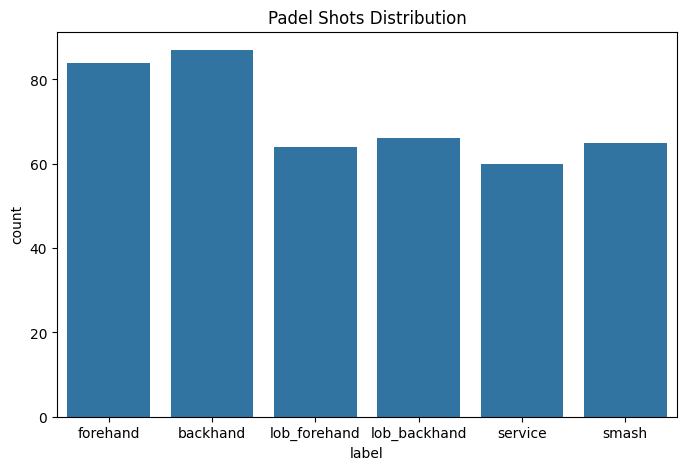

In [14]:
# Conteggio per ogni tipo di colpo
if 'label' in shot_features.columns:
    print("\nDistribution of padel shots in the dataset:")
    print(shot_features['label'].value_counts().sort_index())

    # Grafico della distribuzione
    plt.figure(figsize=(8, 5))
    sns.countplot(data=shot_features, x='label')
    plt.title('Padel Shots Distribution')
    plt.show()


Distribution of player shots:
player
1    143
2    122
3    119
4     42
Name: count, dtype: int64


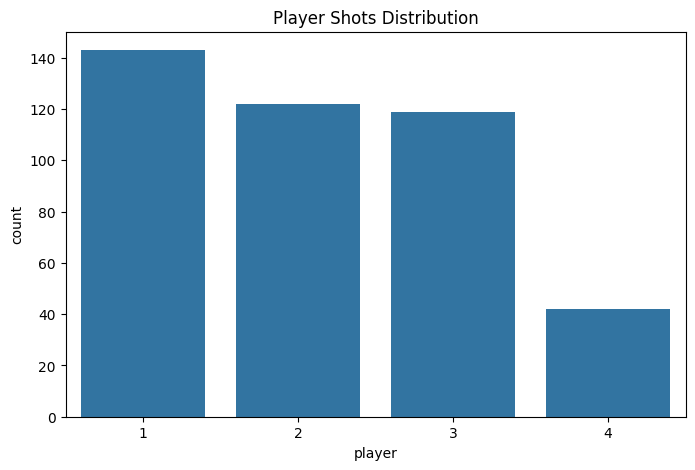

In [15]:
# Conteggio per ogni tipo di giocatore
if 'player' in shot_features.columns:
    print("\nDistribution of player shots:")
    print(shot_features['player'].value_counts().sort_index())

    # Grafico della distribuzione
    plt.figure(figsize=(8, 5))
    sns.countplot(data=shot_features, x='player')
    plt.title('Player Shots Distribution')
    plt.show()

# 3 Training of the model

RANDOM FOREST

In [16]:
def random_forest_OneGroupOut(df):
    y = df['label']
    groups = df['player']

    # Isola SOLO le colonne numeriche
    X = df.select_dtypes(include=['float64', 'int64'])

    # Rimuoviamo colonne numeriche che non sono feature del sensore
    colonne_da_rimuovere = ['shot_id', 'player']
    X = X.drop(columns=[col for col in colonne_da_rimuovere if col in X.columns])

    # --- SETUP CROSS-VALIDATION E MODELLO ---

    # Creiamo una Pipeline: ogni volta che la pipeline riceve dei dati,
    # PRIMA li scala e POI li passa al Random Forest.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
    ])

    logo = LeaveOneGroupOut()

    print("\nAddestramento con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...\n")

    # NOTA l'aggiunta del parametro "groups=groups"
    punteggi = cross_val_score(pipeline, X, y, groups=groups, cv=logo, scoring='accuracy')

    for i, score in enumerate(punteggi):
        print(f"Iterazione {i+1} (Test sul Giocatore escluso): Accuratezza = {score * 100:.2f}%")

    print(f"\nAccuratezza MEDIA Reale: {punteggi.mean() * 100:.2f}% (± {punteggi.std() * 100:.2f}%)")
    print("-" * 50)

    # --- FASE 2: Report Dettagliato e Matrice di Confusione ---

    # Otteniamo le previsioni "pulite" per tutto il dataset (come se fossero tutti dati di test)
    previsioni = cross_val_predict(pipeline, X, y, groups=groups, cv=logo)

    plot_confusion_matrix(y, previsioni, labels=y.unique())

    return pipeline, X, y


Addestramento con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...

Iterazione 1 (Test sul Giocatore escluso): Accuratezza = 50.35%
Iterazione 2 (Test sul Giocatore escluso): Accuratezza = 59.84%
Iterazione 3 (Test sul Giocatore escluso): Accuratezza = 52.94%
Iterazione 4 (Test sul Giocatore escluso): Accuratezza = 95.24%

Accuratezza MEDIA Reale: 64.59% (± 18.03%)
--------------------------------------------------


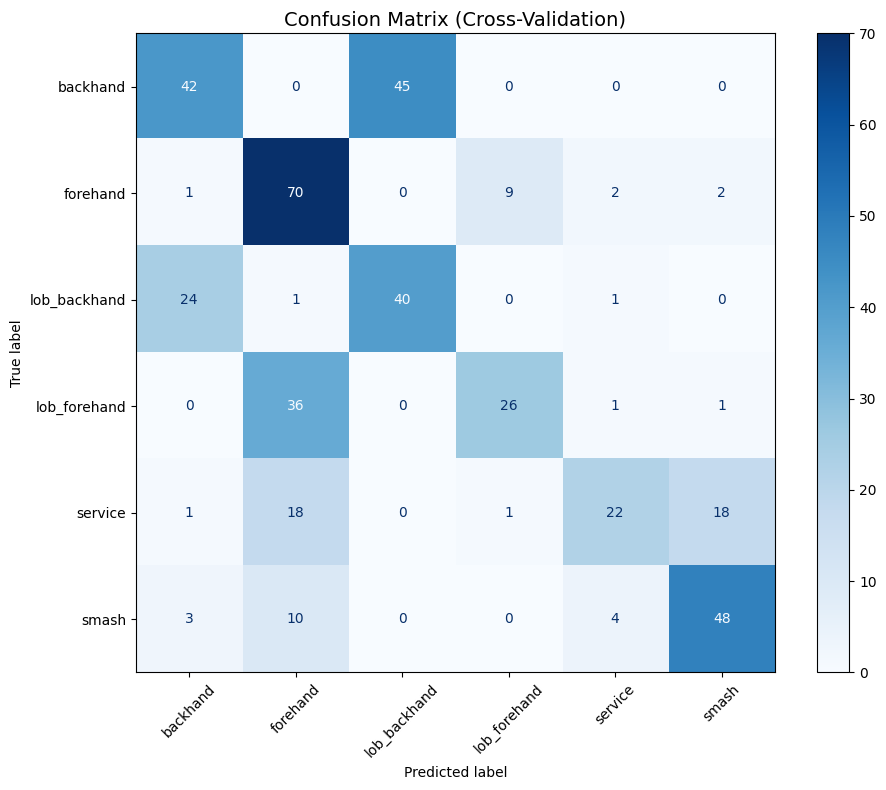

In [17]:
pipeline_rf, X_rf, y_rf = random_forest_OneGroupOut(shot_features)

RANDOM FOREST WITH SKEWNESS and KURTOSIS


Addestramento con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...

Iterazione 1 (Test sul Giocatore escluso): Accuratezza = 50.35%
Iterazione 2 (Test sul Giocatore escluso): Accuratezza = 56.56%
Iterazione 3 (Test sul Giocatore escluso): Accuratezza = 55.46%
Iterazione 4 (Test sul Giocatore escluso): Accuratezza = 97.62%

Accuratezza MEDIA Reale: 65.00% (± 18.98%)
--------------------------------------------------


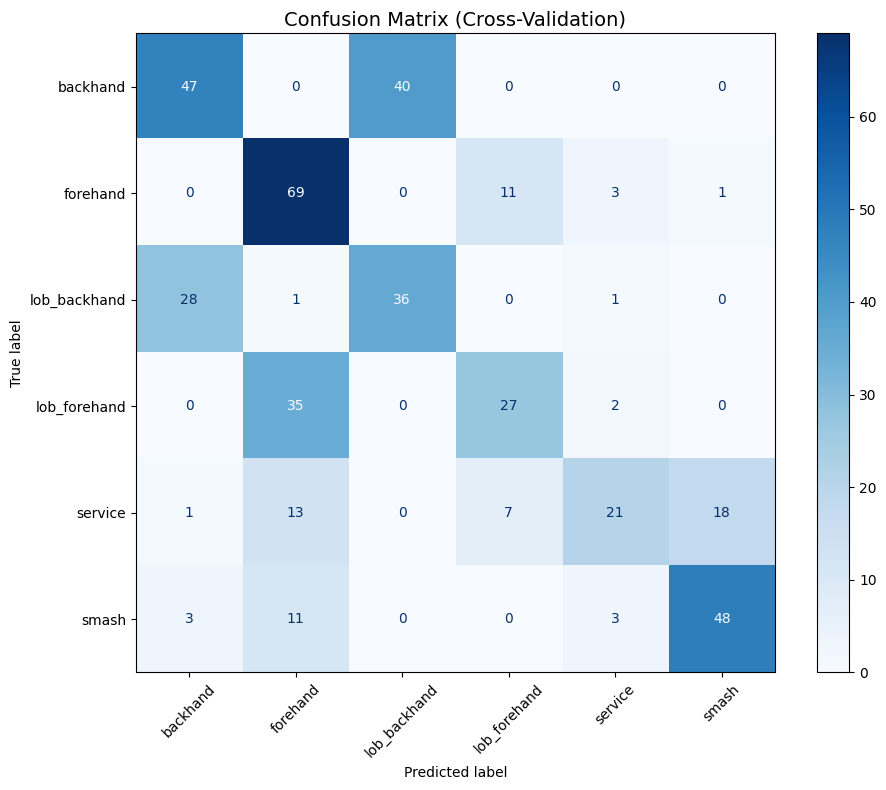

In [18]:
pipeline_rf_SK, X_rf_SK, y_rf_SK = random_forest_OneGroupOut(shot_features_SK)

SUPPORT VECTOR MACHINE

In [19]:
def svm_OneGroupOut(df):
    y = df['label']
    groups = df['player']

    # Isola SOLO le colonne numeriche
    X = df.select_dtypes(include=['float64', 'int64'])

    # Rimuoviamo colonne numeriche che non sono feature del sensore
    colonne_da_rimuovere = ['shot_id', 'player']
    X = X.drop(columns=[col for col in colonne_da_rimuovere if col in X.columns])

    # --- SETUP CROSS-VALIDATION E MODELLO ---

    # Creiamo una Pipeline: ogni volta che la pipeline riceve dei dati,
    # PRIMA li scala (fondamentale per SVM) e POI li passa al modello.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=0.5, random_state=42))
    ])

    logo = LeaveOneGroupOut()

    print("\nAddestramento SVM con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...\n")

    punteggi = cross_val_score(pipeline, X, y, groups=groups, cv=logo, scoring='accuracy')

    for i, score in enumerate(punteggi):
        print(f"Iterazione {i+1} (Test sul Giocatore escluso): Accuratezza = {score * 100:.2f}%")

    print(f"\nAccuratezza MEDIA Reale (SVM): {punteggi.mean() * 100:.2f}% (± {punteggi.std() * 100:.2f}%)")
    print("-" * 50)

    # --- FASE 2: Report Dettagliato e Matrice di Confusione ---

    # Otteniamo le previsioni "pulite" per tutto il dataset (come se fossero tutti dati di test)
    previsioni = cross_val_predict(pipeline, X, y, groups=groups, cv=logo)

    # Richiama la tua funzione personalizzata per plottare la matrice
    plot_confusion_matrix(y, previsioni, labels=y.unique())

    return pipeline, X, y


Addestramento SVM con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...

Iterazione 1 (Test sul Giocatore escluso): Accuratezza = 52.45%
Iterazione 2 (Test sul Giocatore escluso): Accuratezza = 59.02%
Iterazione 3 (Test sul Giocatore escluso): Accuratezza = 56.30%
Iterazione 4 (Test sul Giocatore escluso): Accuratezza = 92.86%

Accuratezza MEDIA Reale (SVM): 65.16% (± 16.16%)
--------------------------------------------------


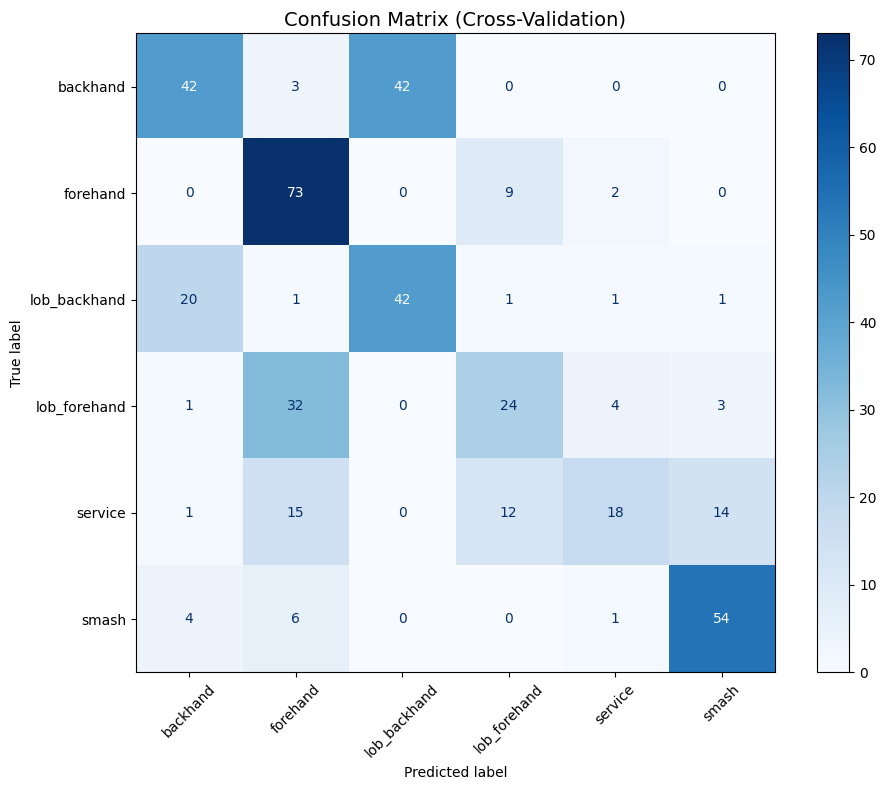

In [20]:
pipeline_svm, X_svm, y_svm = svm_OneGroupOut(shot_features)


Addestramento SVM con Leave-One-Subject-Out (Training su 3 giocatori, Test su 1)...

Iterazione 1 (Test sul Giocatore escluso): Accuratezza = 49.65%
Iterazione 2 (Test sul Giocatore escluso): Accuratezza = 59.84%
Iterazione 3 (Test sul Giocatore escluso): Accuratezza = 52.10%
Iterazione 4 (Test sul Giocatore escluso): Accuratezza = 90.48%

Accuratezza MEDIA Reale (SVM): 63.02% (± 16.29%)
--------------------------------------------------


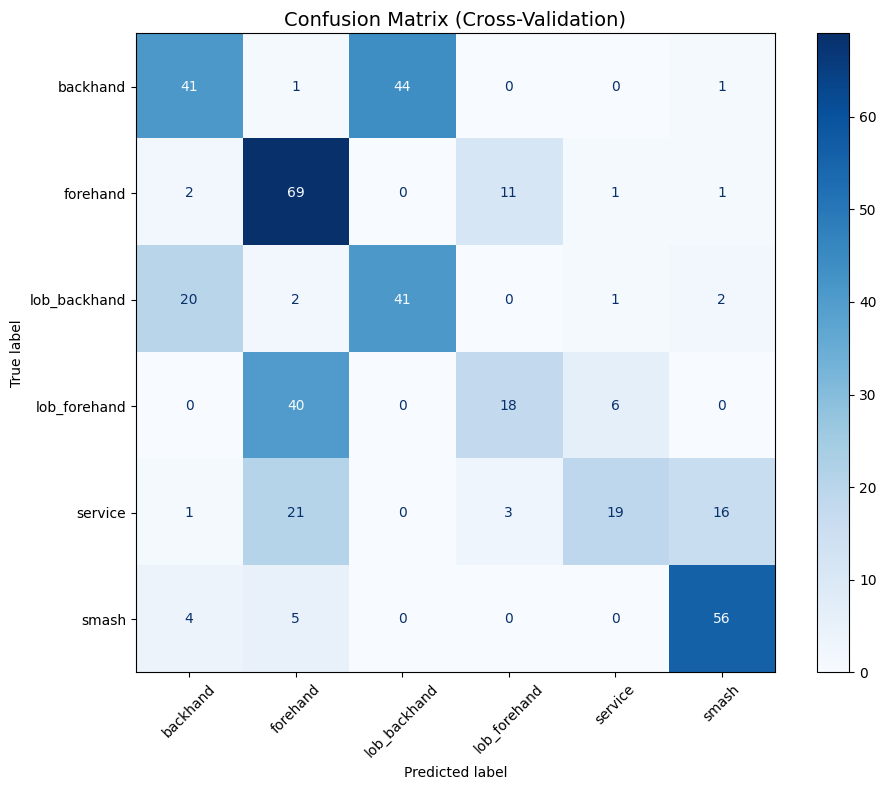

In [21]:
pipeline_svm_SK, X_svm_SK, Y_svm_SK = svm_OneGroupOut(shot_features_SK)

BEST MODEL: SVM without Skewness and Kurtosis [*Accuracy: 65.16%*]

For convenience I'll use the Random Forest model since the accuracy is very similar [*Accuracy: 64.59%*]

# 4 Model Conversion for Android Studio

RANDOM FOREST CONVERSION

In [ ]:
print("\n--- CREAZIONE DEL MODELLO RANDOM FOREST FINALE ---")

# 1. Addestriamo la pipeline su TUTTI I DATI (Training definitivo)
# Ora il modello impara l'esperienza di tutti e 4 i giocatori combinati
pipeline_rf.fit(X_rf, y_rf)
print("Modello finale addestrato su tutto il dataset!")

# 2. SALVATAGGIO CLASSICO (Per usarlo ancora in Python)
# Salva l'intera pipeline (incluso lo scaler) in un file .pkl
# joblib.dump(pipeline, 'modello_svm_completo.pkl')
# print("Salvato 'modello_svm_completo.pkl' per Python.")

# 3. SALVATAGGIO PER ANDROID (Metodo m2cgen visto prima)
modello_rf_puro = pipeline_rf.named_steps['rf']

codice_java = m2c.export_to_java(modello_rf_puro, class_name="PadelModel")

# Construct the full path using the 'path' variable defined earlier
java_file_path = os.path.join(path, "PadelModel_RF.java")
with open(java_file_path, "w") as f:
    f.write(codice_java)

print("Salvato 'PadelModel_RF.java' pronto per Android Studio!")

# ATTENZIONE: Ricordati di estrarre anche i valori dello Scaler per usarli nell'App Java!
scaler_usato = pipeline_rf.named_steps['scaler']
print("\n--- VALORI DELLO SCALER DA COPIARE IN JAVA ---")
print("Medie (Mean):", scaler_usato.mean_)
print("Deviazioni (Scale):", scaler_usato.scale_)


--- CREAZIONE DEL MODELLO RANDOM FOREST FINALE ---
Modello finale addestrato su tutto il dataset!
Salvato 'PadelModel_RF.java' pronto per Android Studio!

--- VALORI DELLO SCALER DA COPIARE IN JAVA ---
Medie (Mean): [  9.26578691   6.16099932  11.6982833   -4.39890836  47.95986454
  -5.24923713  -5.53268105   6.07140353 -20.15572514  10.18990179
  -0.31532567   1.22416826   8.20344144 -26.21688755  13.77001197
  15.79357004  11.88777592  11.38624256   4.30416378  54.31407199
  -0.08080214  -0.17831126   2.61440711  -5.2997294    7.86897869
  -0.23923738   0.08759223   3.14179614  -8.2569865    4.97106218
  -0.29925124  -0.15432833   2.34919149  -6.0039157    4.06487991
   3.9420587    3.13374619   2.88054331   0.81413693  13.41467084]
Deviazioni (Scale): [ 3.57854334  2.82187337  5.64337699  4.41362883 23.92577965  2.35116629
  2.41267997  2.33130586  7.92421268  9.78687755  2.94785457  2.15507152
  2.82163177 13.30026272  6.37708672  4.12965439  2.0844946   5.30362742
  1.89960233 23

SUPPORT VECTOR MACHINE CONVERSION

In [ ]:
print("\n--- CREAZIONE DEL MODELLO SVM FINALE  ---")

# 1. Addestriamo la pipeline su TUTTI I DATI (Training definitivo)
# Ora il modello impara l'esperienza di tutti e 4 i giocatori combinati
pipeline_svm.fit(X_svm, y_svm)
print("Modello finale addestrato su tutto il dataset!")

# 2. SALVATAGGIO CLASSICO (Per usarlo ancora in Python)
# Salva l'intera pipeline (incluso lo scaler) in un file .pkl
# joblib.dump(pipeline, 'modello_svm_completo.pkl')
# print("Salvato 'modello_svm_completo.pkl' per Python.")

# 3. SALVATAGGIO PER ANDROID (Metodo m2cgen visto prima)
# Estraiamo l'SVM "nudo" dalla pipeline per convertirlo in Java
modello_svm_puro = pipeline_svm.named_steps['svm']

codice_java = m2c.export_to_java(modello_svm_puro, class_name="PadelModel")

# Construct the full path using the 'path' variable defined earlier
java_file_path = os.path.join(path, "PadelModel_SVM.java")
with open(java_file_path, "w") as f:
    f.write(codice_java)

print("Salvato 'PadelModel_SVM.java' pronto per Android Studio!")

# ATTENZIONE: Ricordati di estrarre anche i valori dello Scaler per usarli nell'App Java!
scaler_usato = pipeline_rf.named_steps['scaler']
print("\n--- VALORI DELLO SCALER DA COPIARE IN JAVA ---")
print("Medie (Mean):", scaler_usato.mean_)
print("Deviazioni (Scale):", scaler_usato.scale_)


--- CREAZIONE DEL MODELLO FINALE ---
Modello finale addestrato su tutto il dataset!
Salvato 'PadelModel.java' pronto per Android Studio!

--- VALORI DELLO SCALER DA COPIARE IN JAVA ---
Medie (Mean): [  9.26578691   6.16099932  11.6982833   -4.39890836  47.95986454
  -5.24923713  -5.53268105   6.07140353 -20.15572514  10.18990179
  -0.31532567   1.22416826   8.20344144 -26.21688755  13.77001197
  15.79357004  11.88777592  11.38624256   4.30416378  54.31407199
  -0.08080214  -0.17831126   2.61440711  -5.2997294    7.86897869
  -0.23923738   0.08759223   3.14179614  -8.2569865    4.97106218
  -0.29925124  -0.15432833   2.34919149  -6.0039157    4.06487991
   3.9420587    3.13374619   2.88054331   0.81413693  13.41467084]
Deviazioni (Scale): [ 3.57854334  2.82187337  5.64337699  4.41362883 23.92577965  2.35116629
  2.41267997  2.33130586  7.92421268  9.78687755  2.94785457  2.15507152
  2.82163177 13.30026272  6.37708672  4.12965439  2.0844946   5.30362742
  1.89960233 23.36507338  0.4789